In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import numpy as np

# 设置绘图风格和中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 导入数据,涵盖orders,customers,order_itmes,sellers等四张表的基本信息
con = sqlite3.connect('olist.db')

sql_query = """
    SELECT 
        -- 1、订单基本信息
        o.order_id,
        o.order_status,
        o.order_purchase_timestamp,

        -- 2、买家信息
        c.customer_unique_id,
        c.customer_state,
        c.customer_city,

        -- 3、商品和交易信息
        oi.product_id,
        oi.price,
        oi.freight_value,

        -- 4、卖家信息
        s.seller_id,
        s.seller_city,
        s.seller_state,

        -- 5、产品种类
        ca.product_category_name_english

FROM orders o
INNER JOIN customers c ON o.customer_id = c.customer_id
INNER JOIN order_items oi on o.order_id = oi.order_id
INNER JOIN sellers s ON oi.seller_id = s.seller_id
LEFT JOIN products p ON oi.product_id = p.product_id -- 防止部分商品因null而被删除
LEFT JOIN category_translation ca ON p.product_category_name = ca.product_category_name
WHERE o.order_status = 'delivered';

"""

# 读取和检查数据
df_four = pd.read_sql_query(sql_query, con)
df_four.info()
df_four.head()

# 共110197条数据，没有缺失值

<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110197 non-null  str    
 1   order_status                   110197 non-null  str    
 2   order_purchase_timestamp       110197 non-null  str    
 3   customer_unique_id             110197 non-null  str    
 4   customer_state                 110197 non-null  str    
 5   customer_city                  110197 non-null  str    
 6   product_id                     110197 non-null  str    
 7   price                          110197 non-null  float64
 8   freight_value                  110197 non-null  float64
 9   seller_id                      110197 non-null  str    
 10  seller_city                    110197 non-null  str    
 11  seller_state                   110197 non-null  str    
 12  product_category_name_english  108638 non

,order_id,order_status,order_purchase_timestamp,customer_unique_id,customer_state,customer_city,product_id,price,freight_value,seller_id,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,87285b34884572647811a353c7ac498a,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,BA,barreiras,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,aa4383b373c6aca5d8797843e5594415,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,66922902710d126a0e7d26b0e3805106,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,2c9e548be18521d1c43cde1c582c6de8,mogi das cruzes,SP,stationery


In [3]:
# 处理重复值
df_four.duplicated().sum()
df_four.drop_duplicates(inplace=True)

In [4]:
# 描述性统计
df_four.describe()

# 平均价为123，但中位数却只有78，说明存在存在大量高价订单拉高了平均价，符合常规的电商行业情况
# 各数值基本正常

,price,freight_value
count,100196.000000,100196.000000
mean,123.751681,20.069096
std,187.654634,15.780795
min,0.850000,0.000000
25%,40.000000,13.140000
50%,78.000000,16.320000
75%,139.000000,21.190000
max,6735.000000,409.680000


In [5]:
# 转换时间格式
df_four['order_purchase_timestamp'] = pd.to_datetime(df_four['order_purchase_timestamp'], errors='coerce')

In [6]:
# 处理业务噪音
df_four = df_four[df_four['order_purchase_timestamp'].dt.year != 2016].reset_index()

# 由于2016年平台还处于试营阶段，订单量较少，为保证分析的准确性，将2016年的数据删掉

In [7]:
# =========== 维度一：核心指标大盘 ===================

# 总GMV
total_sale = df_four['price'].sum()
print(f'总GMV:{total_sale:.2f}')

# 总订单量
total_orders= df_four['order_id'].count()
print(f'总订单量:{total_orders:.2f}')

# 人流量
total_customer = df_four['customer_unique_id'].nunique()
print(f'人流量:{total_customer}')

# 活跃商家数(有卖过的东西的商家)
total_seller = df_four['seller_id'].nunique()
print(f'活跃商家数:{total_seller}')

# 客单价
avg_price = total_sale / total_orders
print(f'客单价:{avg_price:.2f}')

# 总订单量与人流量十分接近，说明回头客非常少，接下来可以进行用户分层，进一步探究平台的用户结构，以便后续业务进行针对性调整

总GMV:12361900.18
总订单量:99915.00
人流量:93104
活跃商家数:2945
客单价:123.72


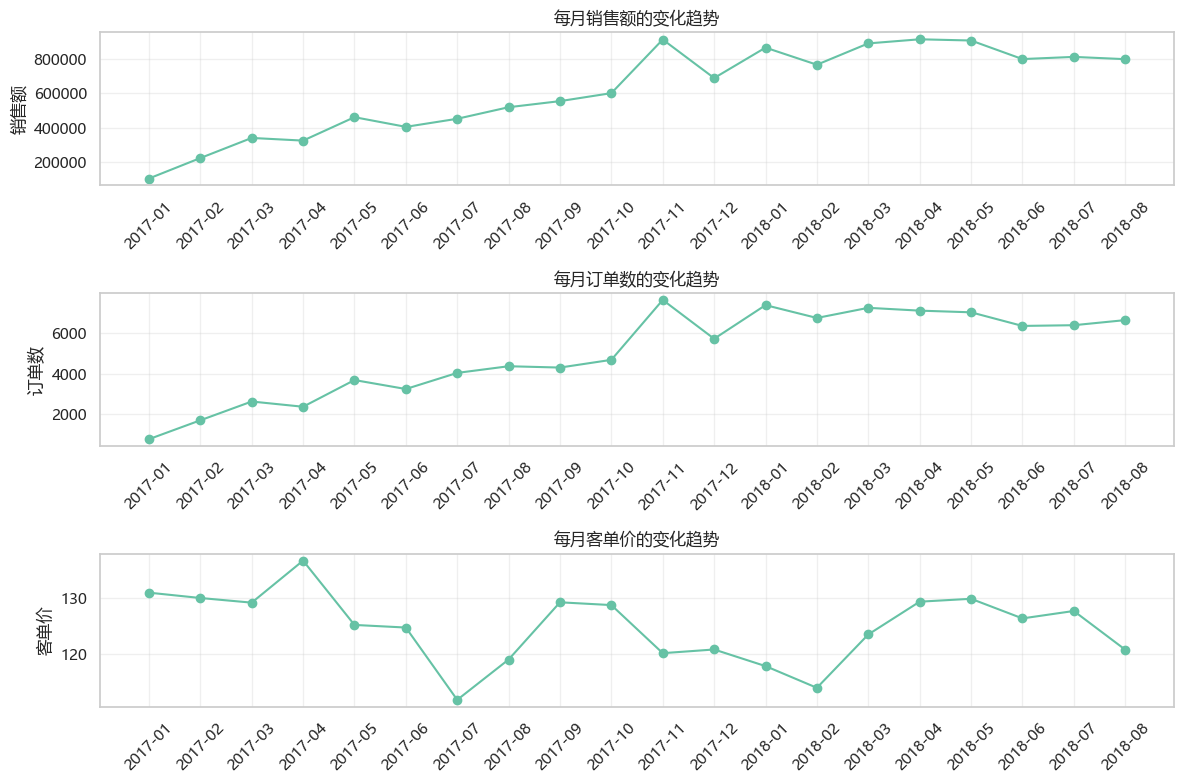

In [8]:
# ==================== 维度二：时间趋势分析 =====================

# 统计每月的GMV、订单数和客单价
monthly_gmv = df_four.groupby(df_four['order_purchase_timestamp'].dt.to_period('M'))['price'].sum()
monthly_orders = df_four.groupby(df_four['order_purchase_timestamp'].dt.to_period('M'))['order_id'].count()

monthly_data = df_four.groupby(df_four['order_purchase_timestamp'].dt.to_period('M')).agg(总销售额 = ('price','sum'),
                                                                                               总订单数 = ('order_id','count'))
monthly_avg_price = round(monthly_data['总销售额'] / monthly_data['总订单数'], 2)

# 绘制折线图

plt.figure(figsize=(12, 8)) # 绘制画布
x_label = monthly_gmv.index.astype(str) # 将月份转成字符串形式，强制在x轴上表现出来
sns.set_palette('Set2') # 自动添加颜色

# GMV
plt.subplot(3,1,1)
plt.plot(x_label, monthly_gmv.values, marker='o')
plt.ylabel('销售额')
plt.title('每月销售额的变化趋势')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# 订单数
plt.subplot(3,1,2)
plt.plot(x_label, monthly_orders.values, marker='o')
plt.ylabel('订单数')
plt.title('每月订单数的变化趋势')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

# 客单价
plt.subplot(3,1,3)
plt.plot(x_label, monthly_avg_price.values, marker='o')
plt.ylabel('客单价')
plt.title('每月客单价的变化趋势')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 每月销售额的变化趋势和订单数的变化趋势几乎完全一致，整体上呈现出递增的趋势，两者都在2017-11达到峰值，可见黑色星期五购物节带来了很大的影响
# 客单价的变化趋势相较两者存在一定的波动，大部分都落于120-130的区间内，分别在2017-07和2018-02出现了两次低谷
# 针对销售额和订单数的不断递增，以及客单价长期处于较高状态，这与巴西人的工资水平不符，接下来可进一步探究用户的支付行为，以便增加对用户情况的了解

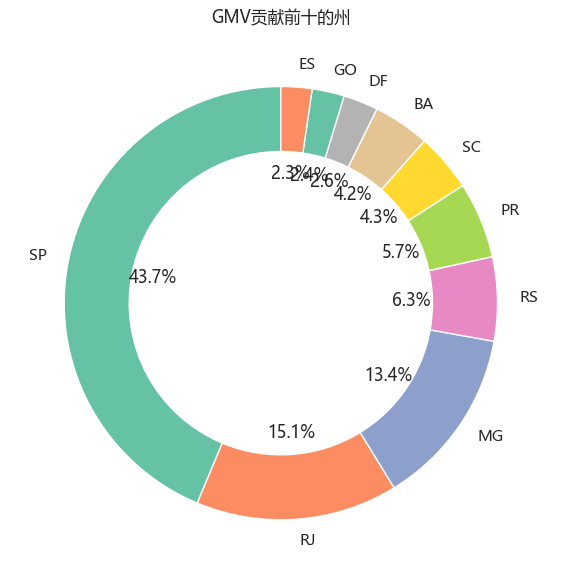

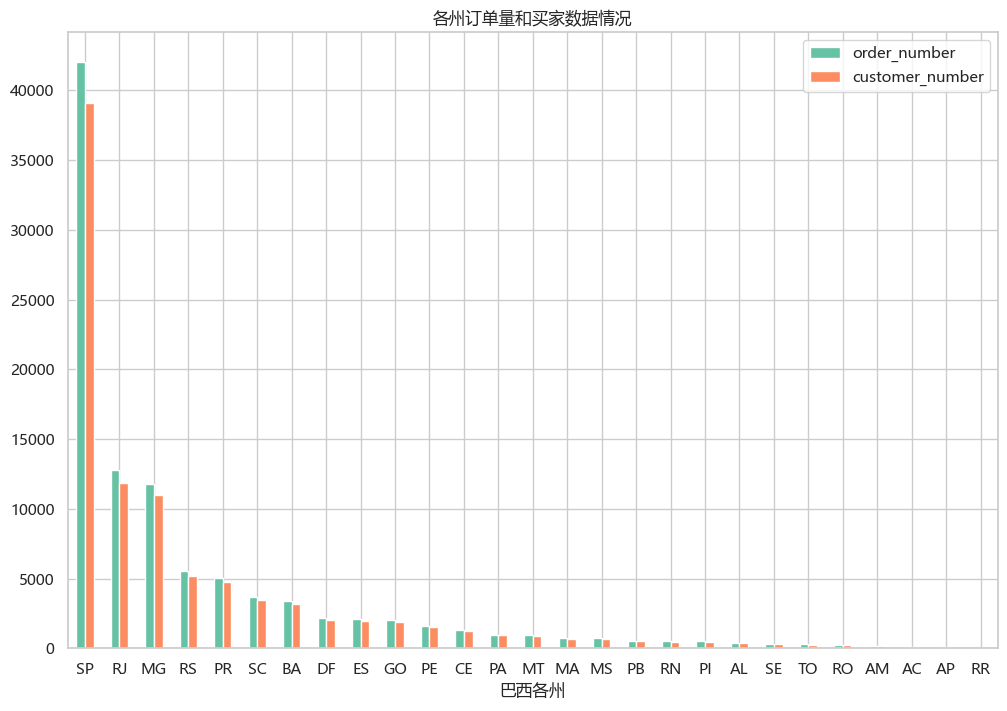

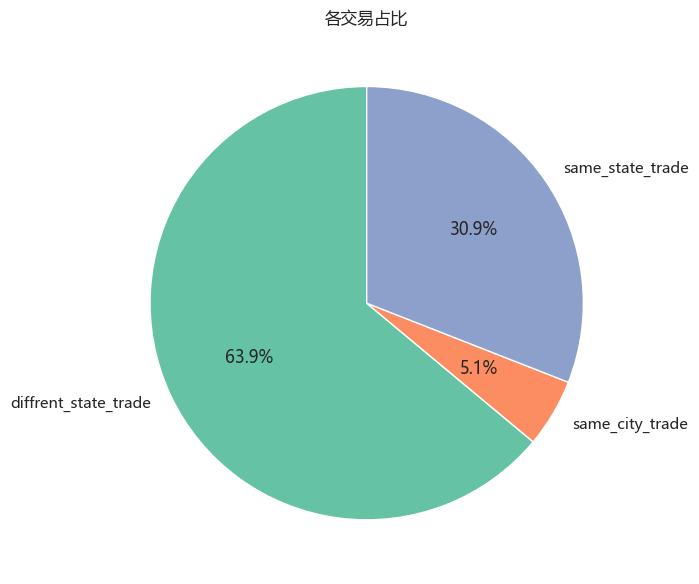

In [9]:
# ========================== 维度三：地域分布分析 ==========================

# GMV贡献占比前十的州
state_gmv = df_four.groupby('customer_state')['price'].sum().sort_values(ascending=False).head(10)

# 各州订单量和买家
state_order_customer = df_four.groupby('customer_state').agg(
                            order_number=('order_id', 'count'),
                            customer_number=('customer_unique_id', 'nunique')).reset_index().sort_values(by= 'order_number', ascending=False)

# 不同类型的交易的占比

# 定义新列
condition = [
    (df_four['customer_state'] == df_four['seller_state']) & (df_four['customer_city'] == df_four['seller_city']), # 同城交易
    (df_four['customer_state'] == df_four['seller_state']) & (df_four['customer_city'] != df_four['seller_city']), # 同州交易
    (df_four['customer_state'] != df_four['seller_state']), # 跨州交易
            ]

colums = ['same_city_trade','same_state_trade','diffrent_state_trade']

df_four['trade_type'] = np.select(condition, colums,default='other')

# 统计各类型交易的订单数占比
trade_type_percent = df_four.groupby('trade_type')['order_id'].count().reset_index()
trade_type_percent.columns = ['trade','order_sum']
trade_type_percent['proportion'] = trade_type_percent['order_sum'] / trade_type_percent['order_sum'].sum()

# ========= 可视化 ==========

sns.set_palette('Set2') 

# GMV
plt.figure(figsize=(8,6))
state_gmv.plot.pie(wedgeprops={'width':0.3},autopct='%1.1f%%',startangle=90)
plt.title('GMV贡献前十的州')
plt.tight_layout()
plt.show()


# 各州订单量和买家
plt.figure(figsize=(12,8))
state_order_customer.set_index('customer_state')[['order_number','customer_number']].plot.bar(ax=plt.gca())
plt.xlabel('巴西各州')
plt.legend()
plt.title('各州订单量和买家数据情况')
plt.xticks(rotation=0)
plt.show()

# 不同类型的交易
plt.figure(figsize=(8,6))
trade_type_percent.set_index('trade')['proportion'].plot.pie(autopct='%1.1f%%',startangle=90)
plt.title('各交易占比')
plt.tight_layout()
plt.show()

# 由图可知，sp州占据了近半的GMV，而且在订单数和人流量上也远高于其他州，其中各州的经济因素是占主导作用的，因此应该倾向于向经济比较发达的几个州倾斜资源
# 在所有交易中，跨州交易占据了60%以上，考虑到巴西幅员辽阔，可以进一步分析运费因素的影响

C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\1425811386.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gmv', y='product_category_name_english', data=top10_gmv, palette='Blues_r')
C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\1425811386.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='orders', y='product_category_name_english', data=top10_orders, palette='Greens_r')


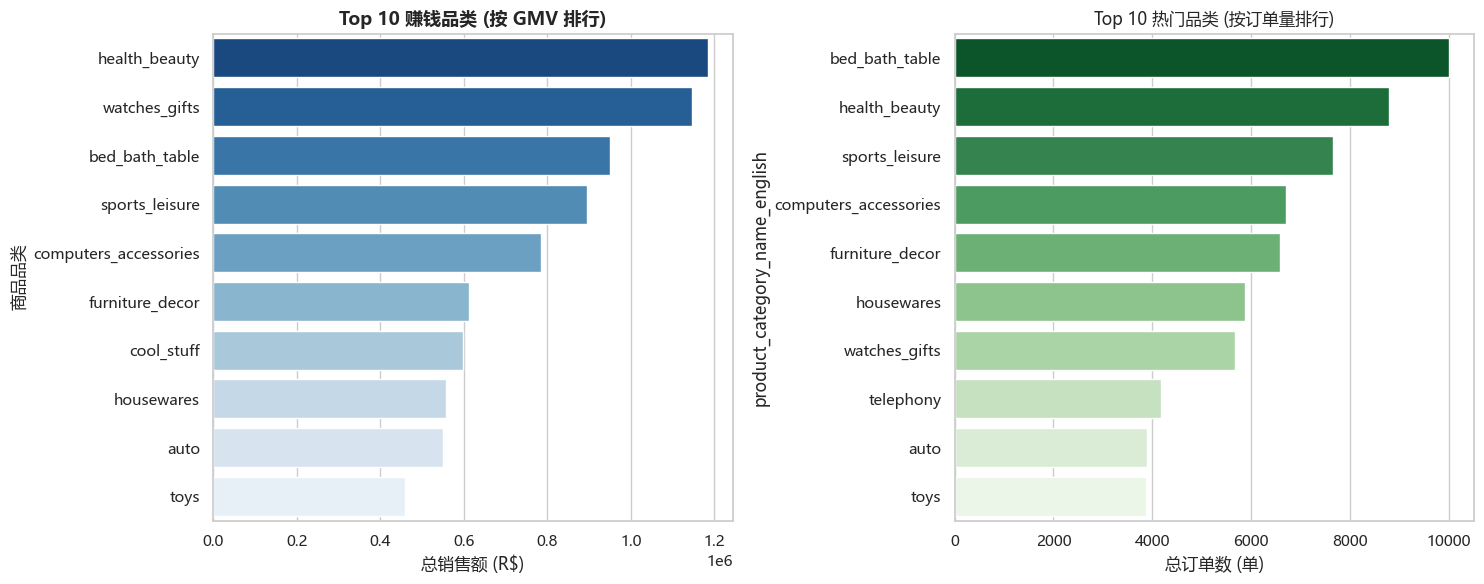

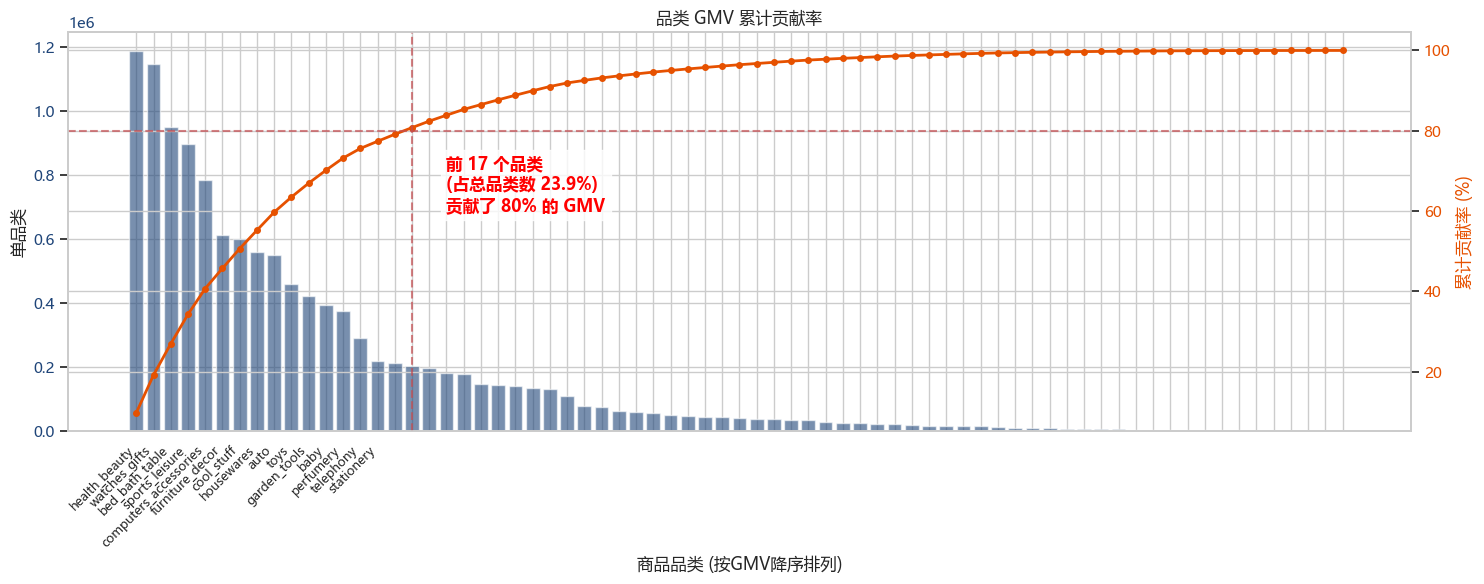

In [10]:
# ============================ 维度四：商品品类 ====================

# 按品类聚合计算 GMV、订单量、平均价格、平均运费
cat_summary = df_four.groupby('product_category_name_english').agg(
    gmv=('price', 'sum'),
    orders=('order_id', 'count'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

# 可视化
plt.figure(figsize=(15, 6))

# 赚钱品类：按 GMV 排行前 10
plt.subplot(1, 2, 1)
top10_gmv = cat_summary.sort_values(by='gmv', ascending=False).head(10)
sns.barplot(x='gmv', y='product_category_name_english', data=top10_gmv, palette='Blues_r')
plt.title('Top 10 赚钱品类 (按 GMV 排行)', fontsize=13, fontweight='bold')
plt.xlabel('总销售额 (R$)')
plt.ylabel('商品品类')

# 热门品类：按订单量排行前 10
plt.subplot(1, 2, 2)
top10_orders = cat_summary.sort_values(by='orders', ascending=False).head(10)
sns.barplot(x='orders', y='product_category_name_english', data=top10_orders, palette='Greens_r')
plt.title('Top 10 热门品类 (按订单量排行)')
plt.xlabel('总订单数 (单)')

plt.tight_layout()
plt.show()

# =================== 品类 GMV 帕累托图 ======================

# 按照 GMV 降序排列
pareto_data = cat_summary.sort_values(by='gmv', ascending=False).reset_index(drop=True)

# 计算累计百分比
pareto_data['cum_percentage'] = 100 * pareto_data['gmv'].cumsum() / pareto_data['gmv'].sum()

fig, ax1 = plt.subplots(figsize=(15, 6))

# 1. 画柱状图 (左轴：各品类 GMV)
color = "#1f4579"
ax1.set_title('品类 GMV 累计贡献率')
ax1.set_xlabel('商品品类 (按GMV降序排列)')
ax1.set_ylabel('单品类')

ax1.bar(pareto_data.index, pareto_data['gmv'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(range(len(pareto_data)), 
           [name if i < 15 else '' for i, name in enumerate(pareto_data['product_category_name_english'])], 
           rotation=45, ha='right', fontsize=9)

# 2. 画折线图 (右轴：累计百分比)
ax2 = ax1.twinx()  # 共享 X 轴，创建双 Y 轴
color = '#e65100'
ax2.set_ylabel('累计贡献率 (%)', color=color, fontsize=12)
ax2.plot(pareto_data.index, pareto_data['cum_percentage'], color=color, marker='o', ms=4, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# 3. 绘制 80% 黄金分割线
ax2.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% 贡献线')
# 找到累计达到 80% 时的品类位置
cutoff_idx = pareto_data[pareto_data['cum_percentage'] >= 80].index[0]
ax2.axvline(x=cutoff_idx, color='r', linestyle='--', alpha=0.7)

# 标注二八定律结论
total_categories = len(pareto_data)
pct_categories = (cutoff_idx + 1) / total_categories * 100
plt.text(cutoff_idx + 2, 60, f"前 {cutoff_idx+1} 个品类\n(占总品类数 {pct_categories:.1f}%)\n贡献了 80% 的 GMV", 
         color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# 美妆、手表礼品等17个品类是平台的核心商品，贡献了80%的销售额，是平台需要着重发展的对象
# 接下来可以进一步了解核心商品背后的卖家竞争格局，形成平台、商品、商家的三方意识，为以后的核心产品扶持政策提供方位

In [11]:
# =============================== 维度五：订单健康情况 ==============================

# -------------- 读取和清洗数据 -----------------

# 读取完整的orders表
sql_query =""" 
SELECT order_id,
       customer_id,
       order_status,
       order_purchase_timestamp,
       order_approved_at,
       order_delivered_carrier_date,
       order_delivered_customer_date,
       order_estimated_delivery_date
FROM orders
"""
df_one = pd.read_sql_query(sql_query,con)

# 处理重复值
df_one.drop_duplicates(inplace=True)

# 转换时间格式
times_col = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']
df_one[times_col] = df_one[times_col].apply(pd.to_datetime)

# 处理业务噪音
df_one = df_one[df_one['order_purchase_timestamp'].dt.year != 2016].reset_index()


C:\Users\dengjiaxin\AppData\Local\Temp\ipykernel_16632\2968703355.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


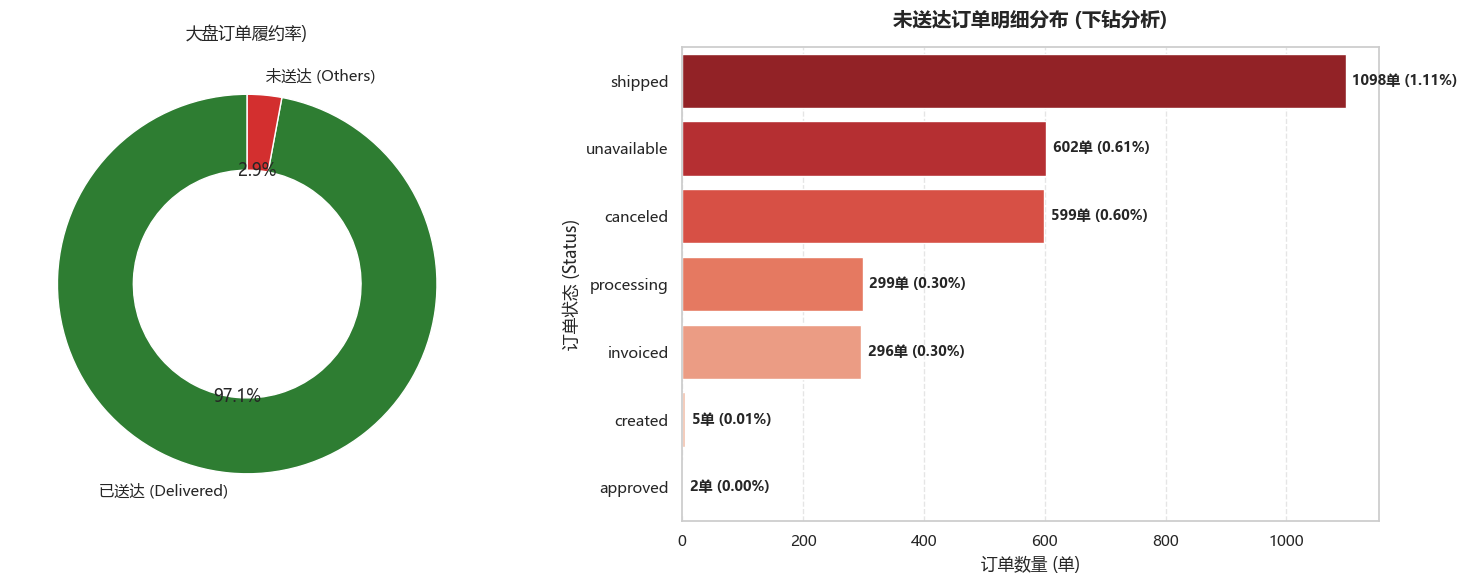

In [ ]:
# ----------------- 数据分析 --------------------

# 1. 计算各状态的数量
status_counts = df_one['order_status'].value_counts().reset_index()
status_counts.columns = ['order_status', 'count']
status_counts['percentage'] = status_counts['count'] / status_counts['count'].sum()

# 2. 将数据分为 "已送达" 和 "非已送达" 两大类
delivered_count = status_counts[status_counts['order_status'] == 'delivered']['count'].sum()
others_count = status_counts[status_counts['order_status'] != 'delivered']['count'].sum()

macro_data = pd.DataFrame({
    'category': ['已送达 (Delivered)', '未送达 (Others)'],
    'count': [delivered_count, others_count]
})

# 3. 过滤出“未送达”的明细数据（排除 delivered）
non_delivered_details = status_counts[status_counts['order_status'] != 'delivered'].copy()

# ======== 开始画图 ========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_palette('Pastel1')

# ---- 左图：大盘履约率（圆环图） ----
ax1.pie(
    macro_data['count'], 
    labels=macro_data['category'],
    autopct='%1.1f%%', 
    startangle=90,
    colors=['#2e7d32', '#d32f2f'], 
    wedgeprops=dict(width=0.4, edgecolor='w') 
)
ax1.set_title('大盘订单履约率)')

# ---- 右图：未送达订单明细下钻（水平条形图） ----
# 按照数量从大到小排序
non_delivered_details = non_delivered_details.sort_values(by='count', ascending=False)

sns.barplot(
    x='count', 
    y='order_status', 
    data=non_delivered_details, 
    ax=ax2, 
    palette='Reds_r' 
)

# 在条形图右侧显示具体数量和占比
for i, row in enumerate(non_delivered_details.itertuples()):
    ax2.text(
        row.count + (non_delivered_details['count'].max() * 0.01), 
        i, 
        f"{row.count}单 ({row.percentage:.2%})", 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

ax2.set_title('未送达订单明细分布 (下钻分析)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('订单数量 (单)')
ax2.set_ylabel('订单状态 (Status)')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

# 调整布局
plt.tight_layout()
plt.show()

# 平台整体履约率达97%，运行状态较为健康
# 未履约的订单虽然只占3%，但是其中超过三分之一都是在途中(shipped),说明有大量订单卡在了运输途中
# 由此可以看出物流运输存在一定问题，接下来可进一步分析物流情况